In [1]:
import numpy as np
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
from utils import spectral_response
from example_GMM import calculate_gmfs, parallel_processing_sa
import pyrotd
#mpl.rcParams['figure.figsize'] = [10, 5]
#mpl.rcParams['figure.dpi'] = 300

from tqdne.conf import Config
config = Config()
dataset_path = "/store/sdsc/sd28/wforms_GAN_input_v20220805.h5"
dataset_path

'/store/sdsc/sd28/wforms_GAN_input_v20220805.h5'

In [2]:
from tqdne.dataset import SampleDataset
from tqdne.representations import Signal


train_dataset = SampleDataset(config.datasetdir / config.data_train, Signal())
test_dataset = SampleDataset(config.datasetdir / config.data_test, Signal())

#combine train and test datasets
waveforms = np.concatenate([train_dataset.waveforms, test_dataset.waveforms])
features = np.concatenate([train_dataset.features, test_dataset.features])
waveforms.shape, features.shape 

((212598, 3, 5501), (212598, 4))

In [3]:
for i in range(features.shape[-1]):
    print(i)
    print(f'Feature {config.features_keys[i]} --  min: {np.nanmin(features[:, i])}, max: {np.ma.masked_invalid(features[:, i]).max()}, max_inf: {np.max(features[:, i])}, min_inf: {np.min(features[:, i])}')

0
Feature hypocentral_distance --  min: 3.9779791831970215, max: 179.99957275390625, max_inf: 179.99957275390625, min_inf: 3.9779791831970215
1
Feature is_shallow_crustal --  min: 0.0, max: 1.0, max_inf: 1.0, min_inf: 0.0
2
Feature magnitude --  min: 4.5, max: 9.083505630493164, max_inf: 9.083505630493164, min_inf: 4.5
3
Feature vs30 --  min: -1.0, max: 2100.0, max_inf: 2100.0, min_inf: -1.0


In [4]:
print("Number of shallow crustal envents: ", int(np.sum(features[:, 1])))
# idx = np.where(features[:,1] == 1)
# waveforms = waveforms[idx[0],:,:]
# features = features[idx[0],:]
waveforms.shape, features.shape

Number of shallow crustal envents:  52076


((212598, 3, 5501), (212598, 4))

In [12]:
##### define distance bins
dist_bins = np.array([0, 30, 50, 70, 90, 110, 150, 170])
mag_bins = np.array([4.9, 5.1, 5.5, 6.0, 6.5, 7, 7.5, 8])
imag = 5
imag = [5, 0, 2, 4, 6]
imag = 1
# divide samples in dist_bins
dist_bins_samples = []
mag_bins_samples = []
waveforms_samples = []
is_shallow_crustal_samples = []
vs30_samples = []

max_num = 100
for i in range(len(dist_bins) - 1):
    mask2 = (features[:, 2] >= mag_bins[imag]) & (features[:, 2] < mag_bins[imag + 1])
    mask3 = (features[:, 3] >= 250) & (features[:, 3] <= 350)
    mask = mask2 & mask3
    temp1 = waveforms[mask][:max_num]
    print(temp1.shape)
    waveforms_samples.append(np.nan_to_num((waveforms[mask][:max_num])))
    dist_bins_samples.append(np.nan_to_num((features[mask,0][:max_num])))
    is_shallow_crustal_samples.append(np.nan_to_num((features[mask,1][:max_num])))
    mag_bins_samples.append(np.nan_to_num((features[mask,2][:max_num])))
    vs30_samples.append(np.nan_to_num((features[mask,3][:max_num])))

# convert to array
magnitude = np.round((mag_bins[imag]+mag_bins[imag+1])/2, decimals=1)
print(np.mean(mag_bins_samples))

(100, 3, 5501)
(100, 3, 5501)
(100, 3, 5501)
(100, 3, 5501)
(100, 3, 5501)
(100, 3, 5501)
(100, 3, 5501)
5.2779684


## Generating waveform

In [7]:
import numpy as np
import torch
import os

from pathlib import Path
from tqdne.utils import *
from tqdne.conf import Config
import pickle

/users/kpalguna/miniconda3/envs/tqdne/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/users/kpalguna/miniconda3/envs/tqdne/lib/python3.11/site-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/users/kpalguna/miniconda3/envs/tqdne/lib/python3.11/site-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(


In [8]:
dataset_folder = "gm0/model/"
model_path_str = dataset_folder + "ddim-pred:sample-2D-downsampling:1_LogSpectrogram-hop_size:16stft_channels:128"
print(model_path_str)
import os
os.getcwd()

gm0/model/ddim-pred:sample-2D-downsampling:1_LogSpectrogram-hop_size:16stft_channels:128


'/users/kpalguna'

In [9]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.cuda.empty_cache()
else: 
    device = torch.device('cpu')

torch.cuda.is_available(), device

(False, device(type='cpu'))

2024-06-05 14:46:07 - root - INFO - Last checkpoint is : gm0/model/ddim-pred:sample-2D-downsampling:1_LogSpectrogram-hop_size:16stft_channels:128/name=0_epoch=91-val_loss=0.01.ckpt
/users/kpalguna/miniconda3/envs/tqdne/lib/python3.11/site-packages/pytorch_lightning/utilities/parsing.py:199: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


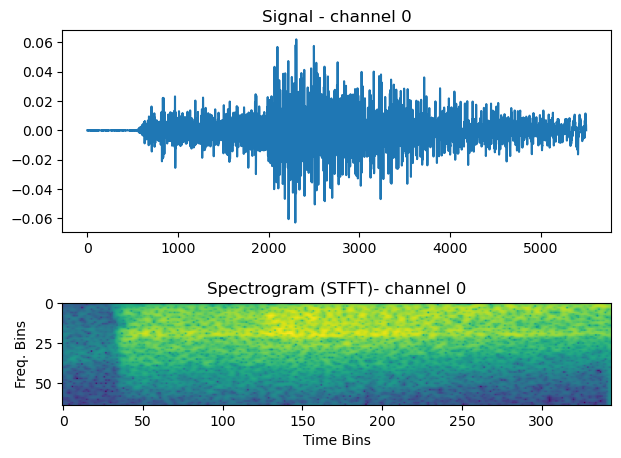

Model: LightningDiffusion
Number of learnable parameters: 38139459
Model size: 458.24 MB
UNet scheme: 
 base num. channels: 32 
 channel multipliers (down/up blocks): (1, 2, 4, 8) 
 num. ResBlocks per down/up block: 2 
 use Attention: True 
 conv. kernel size: 5 
Diffusion prediction type: sample
Learning rate schedule: 
 start: 0.0003 
 scheduler: cosine 
 warmup steps: 500
Batch size: 50
The model was trained on signals with length 5472, as the sampling rate used was 100, whihc is the original sampling rate.
Data representation shape: (1, 3, 64, 344) (batch_size, channels, signal_length)
Data representation name: LogSpectrogram
ckpt file: gm0/model/ddim-pred:sample-2D-downsampling:1_LogSpectrogram-hop_size:16stft_channels:128/name=0_epoch=91-val_loss=0.01.ckpt


In [10]:
model, model_data_repr, ckpt = load_model(Path(model_path_str), use_ddim=False)
model.to(device)
model.eval()
print_model_info(model, model_data_repr, ckpt)

In [11]:
r_hyp = np.logspace(0, 2.4, 1000)

In [13]:
# divide samples in dist_bins
num_floats = 1000
vs30 = np.ones(num_floats) * 250
r_hyp = np.logspace(0, 2.4, num_floats)
is_shallow_crustal = np.ones(num_floats)
mag = np.ones(num_floats) * 5.3

cond_input = np.array([
        r_hyp, 
        is_shallow_crustal,
        mag,
        vs30
    ]).T

print(cond_input.shape)
print("Generate waveforms GM0....")
gen_data = generate_data(model, model_data_repr, raw_output=False, cond_input=cond_input,num_samples=1*cond_input.shape[0], device=device)

print("Now saving the waveforms")

dataset_folder = "GM0_waveforms/"
with open(dataset_folder + 'shakemap_gm0-stft_SA_distance2.pkl', 'wb') as f:
    pickle.dump(gen_data, f)
print('Done writing:' + dataset_folder + 'shakemap_gm0-stft_SA_distance2.pkl')


(1000, 4)
Generate waveforms GM0....
Batch 1/20


100%|██████████| 100/100 [10:49<00:00,  6.49s/it]


Batch 2/20


100%|██████████| 100/100 [10:44<00:00,  6.44s/it]


Batch 3/20


...

Batch 19/20


100%|██████████| 100/100 [10:47<00:00,  6.47s/it]


Batch 20/20


100%|██████████| 100/100 [10:48<00:00,  6.49s/it]


Now saving the waveforms
Done writing:GM0_waveforms/shakemap_gm0-stft_SA_distance2.pkl


In [20]:
dataset_folder = "GM0_waveforms/"
with open(dataset_folder + 'shakemap_gm0-stft_SA_distance2.pkl', 'rb') as f:
    shakemap_data_gen = pickle.load(f)
    print(shakemap_data_gen['waveforms'].shape, shakemap_data_gen['cond'].shape)
waveforms = shakemap_data_gen['waveforms']
distance = shakemap_data_gen['cond'][:,0]

angles = np.arange(0, 180, step=1)
dt = 0.01
T = 0.1
g_inv = 1/9.805
wf_NS = waveforms[:, 0, :]
wf_EW = waveforms[:, 1, :]
periods = np.array([0.1, 0.3, 1, 2])
percentile = 50

sa_mean_01 = parallel_processing_sa(wf_NS, wf_EW, dt, periods, percentile)
sa_mean_01 = np.array(sa_mean_01)

# observation
print("Observation")
waveforms_samples = np.array(waveforms_samples)
dist_bins_samples = np.array(dist_bins_samples)
waveforms_samples2 = waveforms_samples.reshape(waveforms_samples.shape[0]*waveforms_samples.shape[1], waveforms_samples.shape[2], waveforms_samples.shape[3])
dist_bins_samples2 = dist_bins_samples.reshape(dist_bins_samples.shape[0]*dist_bins_samples.shape[1])

NS_obs = waveforms_samples2[:, 0, :]
EW_obs = waveforms_samples2[:, 1, :]

sa_mean_01_obs = parallel_processing_sa(NS_obs, EW_obs, dt, periods, percentile)
sa_mean_01_obs = np.array(sa_mean_01_obs)

(1000, 3, 5472) (1000, 4)
0
100
200
300
400
500
600
700
800
900
Observation
0
100
200
300
400
500
600


In [21]:
print(len(sa_mean_01), len(sa_mean_01_obs))
sa_mean_01_obs = np.array(sa_mean_01_obs)


1000 700


In [30]:
mag = 5.3
rupture_aratio = 1.5
strike = 45
dip = 50
rake = 0
lon = 9.1500
lat = 45.1833
depth = 9
Vs30 = 350
hypocenter = [lon, lat, depth]
imts = ['SA(1.0)']
gmpes = ['BooreEtAl2014', 'Kanno2006Shallow']

gms, jb_distances = calculate_gmfs(mag, rupture_aratio, strike, dip, rake, hypocenter, imts, Vs30, gmpes)


In [31]:
bin_plot = np.logspace(-0.05, 2.4, 20)
dist_filt = []
sa_mean = []
sa_16 = []
sa_84 = []
period = 2
for i in range(len(bin_plot)-1):
    mask = (distance > bin_plot[i]) & (distance <= bin_plot[i+1])
    dist_filt.append(0.5*(bin_plot[i]+bin_plot[i+1]))
    sa_mean.append(np.percentile(sa_mean_01[mask, period]*g_inv, 50))
    sa_16.append(np.percentile(sa_mean_01[mask, period]*g_inv, 16))
    sa_84.append(np.percentile(sa_mean_01[mask, period]*g_inv, 84))

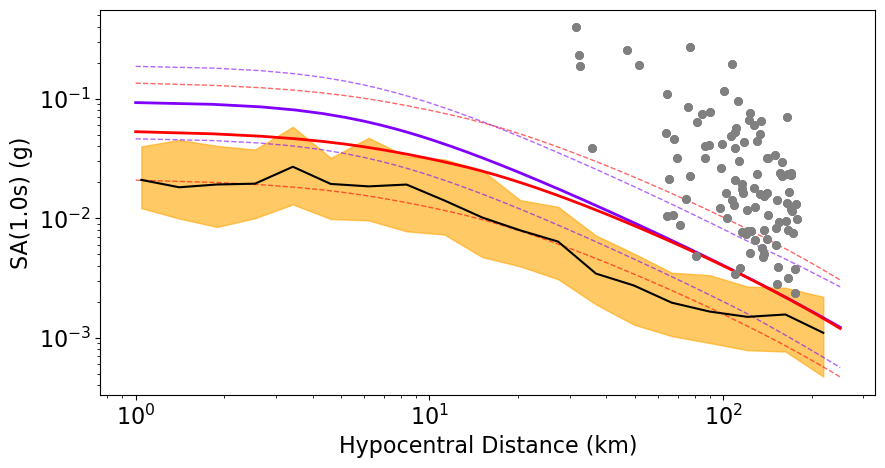

In [32]:
plt.rcParams.update({'font.size': 16})

fig = plt.figure(figsize=(10,5))
ax = fig.gca()
colors = plt.cm.rainbow(np.linspace(0, 1, len(gmpes)))
for imt in range(len(imts)):
        for gsi, color in zip(range(len(gmpes)), colors):
            ax.loglog(jb_distances, np.exp(gms[0, gsi, imt]), linewidth=2, color=color, label=gmpes[gsi])
            ax.loglog(jb_distances, np.exp(gms[0, gsi, imt] + gms[1, gsi, imt]), '--', linewidth=1, color=color, alpha=0.6)
            ax.loglog(jb_distances, np.exp(gms[0, gsi, imt] - gms[1, gsi, imt]), '--', linewidth=1, color=color, alpha=0.6)
# ax.loglog(distance, sa_mean_01[:,0]*g_inv, '^', color='b', markersize=5)
ax.loglog(dist_filt, sa_mean, '-', color='k', markersize=7)
ax.fill_between(dist_filt, sa_16, sa_84, color='orange', alpha=0.6)
ax.loglog(dist_bins_samples2, sa_mean_01_obs[:,0]*g_inv, 'o', color='grey', markersize=5)
ax.set_xlabel('Hypocentral Distance (km)')
ax.set_ylabel('SA(1.0s) (g)')
fig.savefig("SA_sample_1.png", dpi=200, bbox_inches="tight")